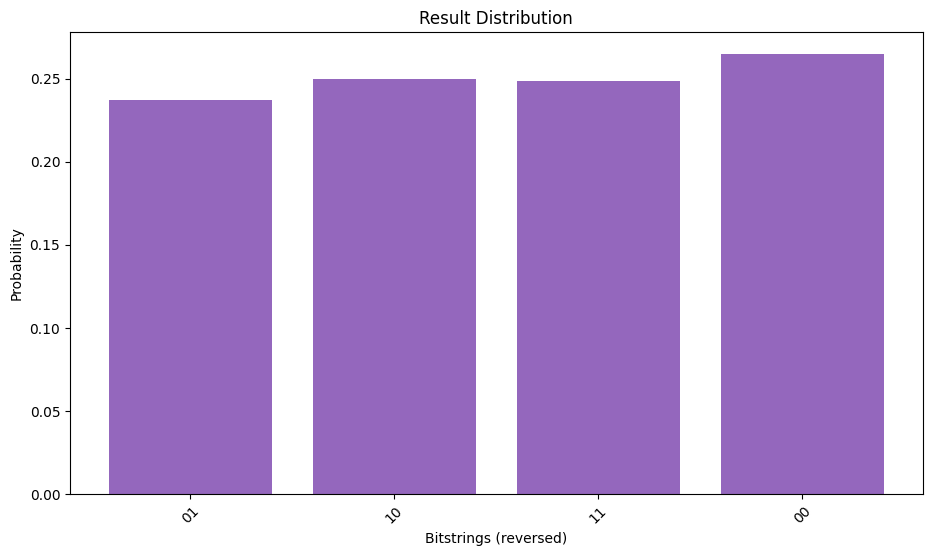

In [11]:
# Here is the installation process 
# First we creat a virtual python environment using terminal on Mac on Command Prompt
"""
   python -m venv name_of_your_virtual_enviroment
   source bin/activate
   pip install qiskit
   pip install qiskit_aer
"""
# Once this installation is complete, you can start writing your programs either using Jupyter notebooks or open a empty file using vim in terminal
""" 
    vi demo.py
"""
# Add this line to the top of the file
""" 
   #!/usr/bin/env python
"""
# For jupyter notebook 
"""
   pip install notebook
"""
# Launch it using jupyter notebook from terminal -- a new tab opens up in your browser

# Now let's build a simple program for sampling a Quantum Circuit 
# We need to import Qiskit primitives to build the circuit


from IPython.display import display, Math, Latex
import matplotlib
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendSamplerV2 as Sampler


num_qubits = 2
clbits = 2
def plot_final_distribution(final_distribution_bin): 

    matplotlib.rcParams.update({"font.size": 10})
    final_bits = final_distribution_bin
    
    fig = plt.figure(figsize=(11, 6))
    ax = fig.add_subplot(1, 1, 1)
    plt.xticks(rotation=45)
    plt.title("Result Distribution")
    plt.xlabel("Bitstrings (reversed)")
    plt.ylabel("Probability")
    ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:purple")
    plt.show()

circuit = QuantumCircuit(num_qubits, clbits)
for i in range(2):
    circuit.h(i)
circuit.measure_all()
circuit.draw("mpl", fold=False, idle_wires=False) 


# create a primitive unit bloc -- a tuple of objecct e.g (circuit, hamiltonian, parameters)
pub = (circuit,)
backend = AerSimulator()
sampler = Sampler(backend= backend)
sampler.options.default_shots = 1000
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
plot_final_distribution(final_distribution_bin)


Another important state is the GHZ state
$$\ket{\psi} = \frac{1}{2}(\ket{000}+\ket{111})$$
We need the two qubit gate called the CNOT gate to build this state
$$ CNOT = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\0 & 0 & 1 & 0 \end{pmatrix} $$
Another way to represent the CNOT operation(gate) is through projective operators
$$CNOT = P_{0}\otimes I + P_{1} \otimes X $$
where
$$ P_{0} = \ket{0}\bra{0} \hspace{0.5cm} P_{1} = \ket{1}\bra{1} $$
Using the Hadamard and CNOT gates we can build the GHZ state. Write a 3-qubit circuit to build the GHZ state